In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/sharmajicoder/student-mental-health-and-burnout/student_mental_health_burnout_1M.csv


In [2]:
path = "/kaggle/input/datasets/sharmajicoder/student-mental-health-and-burnout/student_mental_health_burnout_1M.csv"
data = pd.read_csv(path)
data.head()


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [3]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb

le = LabelEncoder()
data['gender'] = le.fit_transform(data['gender'])
data['risk_level'] = le.fit_transform(data['risk_level'])

scaler = StandardScaler()
data['academic_performance'] = scaler.fit_transform(data[['academic_performance']])
X = data.drop(['mental_health_index', 'risk_level','dropout_risk'],axis = 1)
#target
y_mhi = data['mental_health_index']
y_rl = data['risk_level']
y_dr = data['dropout_risk']


In [4]:
X_train , X_test , y_train , y_test = train_test_split(X, y_mhi , test_size = 0.2,random_state = 42)
model = xgb.XGBRegressor(n_estimators = 100,learning_rate=0.1,max_depth=8,tree_method='hist')

model.fit(X_train,y_train)

prid = model.predict(X_test)

In [5]:
X_train_c , X_test_c , y_train_c , y_test_c = train_test_split(X, y_rl , test_size = 0.2,random_state = 42)

clas_model = xgb.XGBClassifier(n_estimators=100, objective = 'multi:softprob', num_class=3,tree_method='hist')
clas_model.fit(X_train_c, y_train_c)

risk_pred = clas_model.predict(X_test_c)

Mental Health Index - Mean Absolute Error: 0.01
Mental Health Index - R2 Score: 1.00


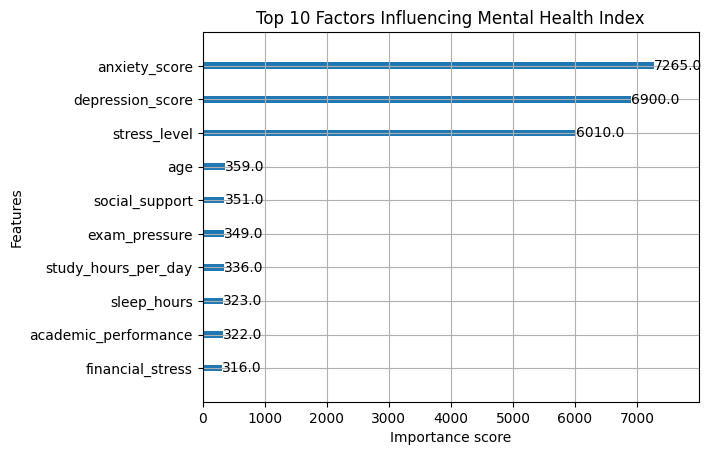

In [6]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Calculate Error
mae = mean_absolute_error(y_test, prid)
r2 = r2_score(y_test, prid)

print(f"Mental Health Index - Mean Absolute Error: {mae:.2f}")
print(f"Mental Health Index - R2 Score: {r2:.2f}")

# Plot Feature Importance
xgb.plot_importance(model, max_num_features=10)
plt.title("Top 10 Factors Influencing Mental Health Index")
plt.show()

Risk Level Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3075
           1       1.00      1.00      1.00    153333
           2       1.00      1.00      1.00     43592

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



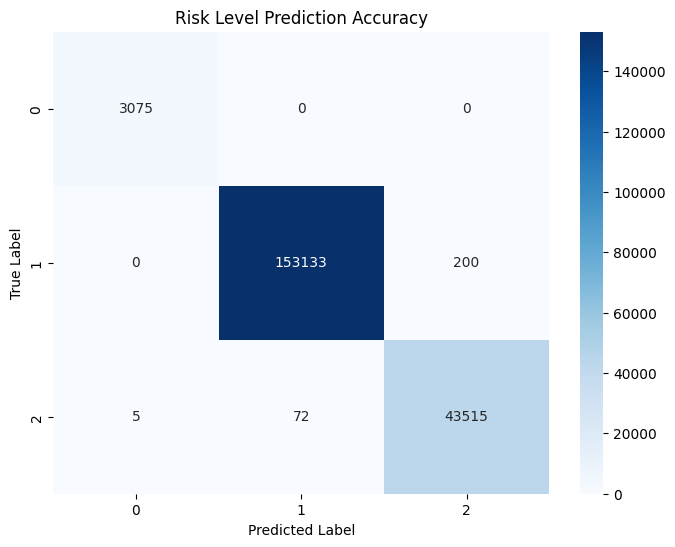

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


print("Risk Level Classification Report:")
print(classification_report(y_test_c, risk_pred))

# Visualizing the Confusion Matrix
cm = confusion_matrix(y_test_c, risk_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Risk Level Prediction Accuracy')
plt.show()